In [ ]:
# Разведочный анализ: посещаемость ресторанов


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

from src.data import prepare

df = prepare(ROOT / "data" / "raw" / "guests.csv")
df.head()

,date,restaurant_id,guests,revenue,is_missing,is_closed,guests_raw,is_outlier
0,2024-10-01,1,141.0,211521.14,0,0,141.0,0
1,2024-10-02,1,153.0,232758.36,0,0,153.0,0
2,2024-10-03,1,127.0,183959.97,0,0,127.0,0
3,2024-10-04,1,202.0,301649.81,0,0,202.0,0
4,2024-10-05,1,187.0,258959.35,0,0,187.0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1309 non-null   datetime64[ns]
 1   restaurant_id  1309 non-null   int64         
 2   guests         1268 non-null   float64       
 3   revenue        1268 non-null   float64       
 4   is_missing     1309 non-null   int64         
 5   is_closed      1309 non-null   int64         
 6   guests_raw     1274 non-null   float64       
 7   is_outlier     1309 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(4)
memory usage: 81.9 KB


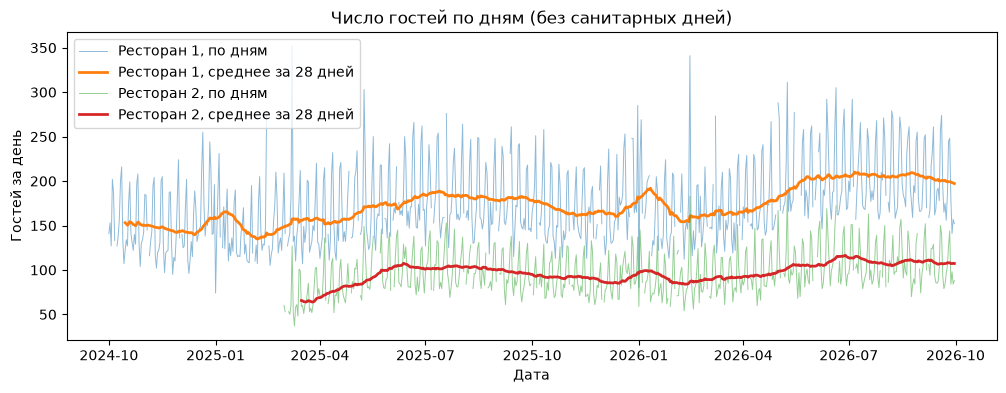

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))

for rid, g in df.groupby("restaurant_id"):
    open_guests = g["guests"].where(g["is_closed"] == 0)
    ax.plot(g["date"], open_guests, lw=0.7, alpha=0.5,
            label=f"Ресторан {rid}, по дням")
    ax.plot(g["date"], open_guests.rolling(28, min_periods=14).mean(), lw=2,
            label=f"Ресторан {rid}, среднее за 28 дней")

ax.set_title("Число гостей по дням (без санитарных дней)")
ax.set_xlabel("Дата")
ax.set_ylabel("Гостей за день")
ax.legend()
plt.show()

Оба ресторана медленно растут, и каждый год повторяется летний пик и декабрьский всплеск. Ресторан 2 открылся в марте 2025 и первые 2–3 месяца набирал посещаемость. Для модели нужны признак текущего уровня (среднее за последние 4 недели), чтобы учитывать рост и раскрутку, и месяц, чтобы учитывать сезон.

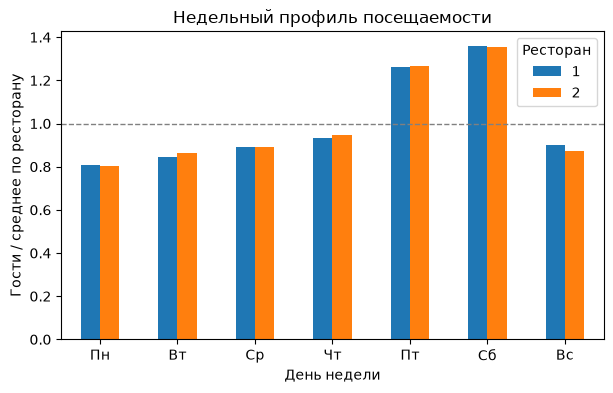

restaurant_id,1,2
dow,,
0,0.81,0.80
1,0.85,0.86
2,0.89,0.89
3,0.93,0.94
4,1.26,1.27
5,1.36,1.35
6,0.90,0.88


In [5]:
open_days = df[df["is_closed"] == 0].copy()
open_days["dow"] = open_days["date"].dt.dayofweek

profile = open_days.groupby(["restaurant_id", "dow"])["guests"].mean().unstack(0)
profile = profile / profile.mean()

fig, ax = plt.subplots(figsize=(7, 4))
profile.plot(kind="bar", ax=ax)
ax.set_xticklabels(["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"], rotation=0)
ax.axhline(1, color="gray", linestyle="--", linewidth=1)
ax.set_title("Недельный профиль посещаемости")
ax.set_xlabel("День недели")
ax.set_ylabel("Гости / среднее по ресторану")
ax.legend(title="Ресторан")
plt.show()

profile.round(2)

Сильнее всего от среднего отличаются пятница (+26%) и суббота (+36%), слабее всего — понедельник (−20%). По загрузке пятница ближе к субботе, чем к будням, поэтому в признаке is_weekend она считается выходным. Форма недели у двух ресторанов совпадает (расхождение ≤ 0.02), значит, одну модель можно учить на обоих ресторанах сразу, а разницу в масштабе учтёт признак уровня. Для модели нужен признак дня недели.